# Noise and Dimensionality

### Goal:
In this notebook, we investigate the conditions in which PCA can successfully recover the hidden latent structure from simulated neural population activity. To do this, we perform two controlled experiments while changing one parameter at a time. First, we will vary the level of observation noise. Second, we vary the number of observed neurons. For each experimental condition, we repeatedly simulate neural activity, apply PCA, and evaluate recovery using reconstruction error (mean squared error), subspace similarity, and correlation with the true latent state. By comparing these metrics across conditions, we can determine how noise and population size influence PCA's ability to recover the underlying low-dimensional dynamics. 

In [1]:
import numpy as np
from matplotlib.pyplot import subplots
import pandas as pd
from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from dynamics import *
from simulations import *
from dimensionality_reduction import *
from metrics import *

### Generate Latent Dynamics

In [2]:
theta = np.pi/4
r = 0.98
x0 = np.array([1, 1])
T = 100
noise_std = 0.1
A = damped_rotation_matrix(theta, r)
X = simulate_linear_system(A, x0, T)

## Experiment 1: Varying Observation Noise

In [3]:
# Noise Levels
noise_stds = np.array([0.00, 0.10, 0.20, 0.40, 0.80, 1.00, 1.50, 2.00, 2.50, 3.0, 5.0])

n_neurons = 100
latent_dim = x0.shape[0]
n_components = 2

# Store Metrics
n_repeats = 30
mean_mse, std_mse = [], []
mean_similarity, std_similarity = [], []
mean_correlation, std_correlation = [], []

for noise_std in noise_stds:
        
    # Store Run Metrics
    mse_runs = []
    similarity_runs = []
    correlation_runs = []

    master_rng = np.random.default_rng(0)
    for _ in range(n_repeats):
        rng = np.random.default_rng(master_rng.integers(1_000_000))
        
        # Run Simulation
        C = generate_observation_matrix(n_neurons, latent_dim, scale=1.0, rng=rng)
        Y_clean = X @ C.T
        Y_noisy = add_observation_noise(Y_clean, noise_std, rng=rng)
    
        # Run PCA
        Z_pca, pca_model = run_pca(Y_noisy, n_components)
    
        # Compute MSE
        Y_hat = reconstruct_from_pca(Z_pca, pca_model)
        mse = reconstruction_error(Y_noisy, Y_hat)
        mse_runs.append(mse)
    
        # Compute Subspace Similarity
        principle_angles, similarity = subspace_similarity(X, Z_pca)
        similarity_runs.append(similarity)
    
        # Compute Mean Max Latent Correlation
        correlation = mean_max_latent_correlation(X, Z_pca)
        correlation_runs.append(correlation)

    mean_mse.append(np.mean(mse_runs))
    std_mse.append(np.std(mse_runs))

    mean_similarity.append(np.mean(similarity_runs))
    std_similarity.append(np.std(similarity_runs))

    mean_correlation.append(np.mean(correlation_runs))
    std_correlation.append(np.std(correlation_runs))

## Experiment 1: Results

,noise_std,mean_mse,std_mse,mean_similarity,std_similarity,mean_correlation,std_correlation
0,0.0,0.0000,0.0000,1.0000,0.0000,0.8990,0.0734
1,0.1,0.0095,0.0001,0.9996,0.0001,0.8979,0.0759
2,0.2,0.0380,0.0005,0.9983,0.0003,0.8959,0.0788
3,0.4,0.1521,0.0022,0.9933,0.0012,0.8912,0.0832
4,0.8,0.6081,0.0086,0.9729,0.0047,0.8816,0.0859
5,1.0,0.9498,0.0135,0.9576,0.0074,0.8720,0.0916
6,1.5,2.1347,0.0303,0.9042,0.0166,0.8392,0.1055
7,2.0,3.7889,0.0539,0.8298,0.0294,0.8207,0.0867
8,2.5,5.9084,0.0840,0.7355,0.0444,0.7906,0.0642
9,3.0,8.4875,0.1209,0.6173,0.0701,0.7221,0.0654


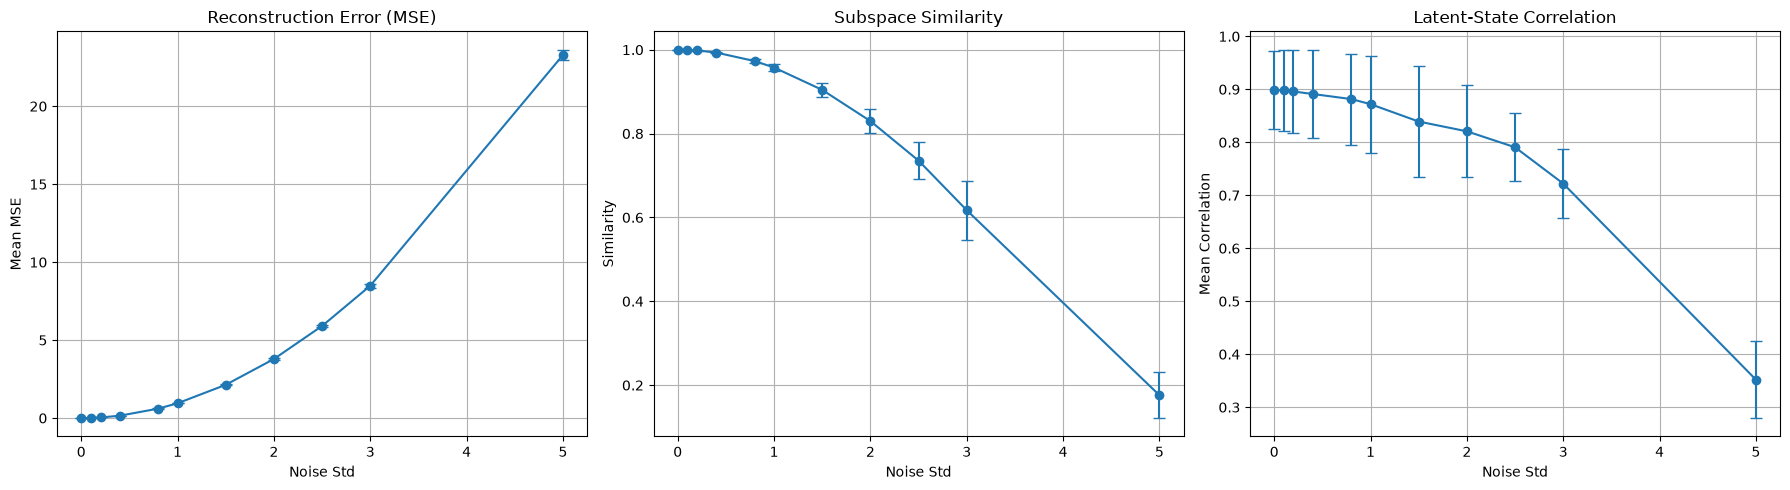

In [4]:
# Data Frame
results_df = pd.DataFrame({
    "noise_std": noise_stds,
    "mean_mse": mean_mse,
    "std_mse": std_mse,
    "mean_similarity": mean_similarity,
    "std_similarity": std_similarity,
    "mean_correlation": mean_correlation,
    "std_correlation": std_correlation,
})
display(results_df.round(4))

# Plotting

fig, ax = subplots(1, 3, figsize=(18, 5), sharex=True)

ax[0].errorbar(noise_stds, mean_mse, yerr=std_mse, fmt='o-', capsize=4)
ax[0].set_title("Reconstruction Error (MSE)")
ax[0].set_xlabel("Noise Std")
ax[0].set_ylabel("Mean MSE")
ax[0].grid()

# Subspace Similarity
ax[1].errorbar(noise_stds, mean_similarity, yerr=std_similarity, fmt='o-', capsize=4)
ax[1].set_title("Subspace Similarity")
ax[1].set_xlabel("Noise Std")
ax[1].set_ylabel("Similarity")
ax[1].grid()

# Correlation 
ax[2].errorbar(noise_stds, mean_correlation, yerr=std_correlation, fmt='o-', capsize=4)
ax[2].set_title("Latent-State Correlation")
ax[2].set_xlabel("Noise Std")
ax[2].set_ylabel("Mean Correlation")
ax[2].grid()

fig.tight_layout()

The results show that PCA reliably recovers the underlying latent structure when observation noise levels are low. At small noise levels, the reconstruction error is close to zero while the subspace similarity score remains nearly one. This indicates that the principal component recovers almost the same two-dimensional subspace as the true latent dynamics. The latent-state correlation is also high, suggesting a strong correlation between the principal components and the latent variables. However, even with zero noise, latent-state correlation is approximately 0.90. Ideally, the value should be approximately 1.0. This suggests that the metric is being affected by PCA's arbitrary rotation within the recovered two-dimensional subspace instead of the actual recovery error, confirming a known limitation of Pearson correlations. 

As the observation noise increases, reconstruction error increases while both subspace similarity and latent-state correlation both decrease. This reflects the fact that observation noise increasingly dominates the covariance structure of the neural population making it more difficult for PCA to distinguish signal from random variability. 

The relatively small standard deviations across repeated simulations indicate these results are highly reproducible. Overall, these experiments demonstrate that PCA is robust to modest levels of observation noise and gradually loses its ability to recover the latent dynamics as the signal-to-noise ratio decreases.

## Experiment 2: Varying Number of Neurons

In [5]:
# Numbers of Neurons
ns = np.array([5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 500])

noise_std = 1.5
latent_dim = x0.shape[0]
n_components = 2

# Store Metrics
n_repeats = 30
mean_mse, std_mse = [], []
mean_similarity, std_similarity = [], []
mean_correlation, std_correlation = [], []

for n in ns:
        
    # Store Run Metrics
    mse_runs = []
    similarity_runs = []
    correlation_runs = []

    master_rng = np.random.default_rng(0)
    for _ in range(n_repeats):
        rng = np.random.default_rng(master_rng.integers(1_000_000))
        
        # Run Simulation
        C = generate_observation_matrix(n, latent_dim, scale=1.0, rng=rng)
        Y_clean = X @ C.T
        Y_noisy = add_observation_noise(Y_clean, noise_std, rng=rng)
    
        # Run PCA
        Z_pca, pca_model = run_pca(Y_noisy, n_components)
    
        # Compute MSE
        Y_hat = reconstruct_from_pca(Z_pca, pca_model)
        mse = reconstruction_error(Y_noisy, Y_hat)
        mse_runs.append(mse)
    
        # Compute Subspace Similarity
        principle_angles, similarity = subspace_similarity(X, Z_pca)
        similarity_runs.append(similarity)
    
        # Compute Mean Max Latent Correlation
        correlation = mean_max_latent_correlation(X, Z_pca)
        correlation_runs.append(correlation)

    mean_mse.append(np.mean(mse_runs))
    std_mse.append(np.std(mse_runs))

    mean_similarity.append(np.mean(similarity_runs))
    std_similarity.append(np.std(similarity_runs))

    mean_correlation.append(np.mean(correlation_runs))
    std_correlation.append(np.std(correlation_runs))

## Experiment 2: Results

,Number of Neurons,mean_mse,std_mse,mean_similarity,std_similarity,mean_correlation,std_correlation
0,5,1.2227,0.1050,0.2683,0.1106,0.4422,0.1077
1,10,1.6848,0.0706,0.4096,0.1244,0.5720,0.1039
2,20,1.9519,0.0648,0.6219,0.0771,0.6977,0.0853
3,30,2.0215,0.0549,0.7189,0.0514,0.7703,0.0676
4,50,2.0832,0.0481,0.8223,0.0255,0.8167,0.0792
5,75,2.1161,0.0436,0.8763,0.0199,0.8418,0.0765
6,100,2.1347,0.0303,0.9042,0.0166,0.8392,0.1055
7,150,2.1517,0.0259,0.9371,0.0088,0.8548,0.0817
8,200,2.1570,0.0233,0.9513,0.0063,0.8746,0.0815
9,300,2.1670,0.0204,0.9672,0.0041,0.8930,0.0834


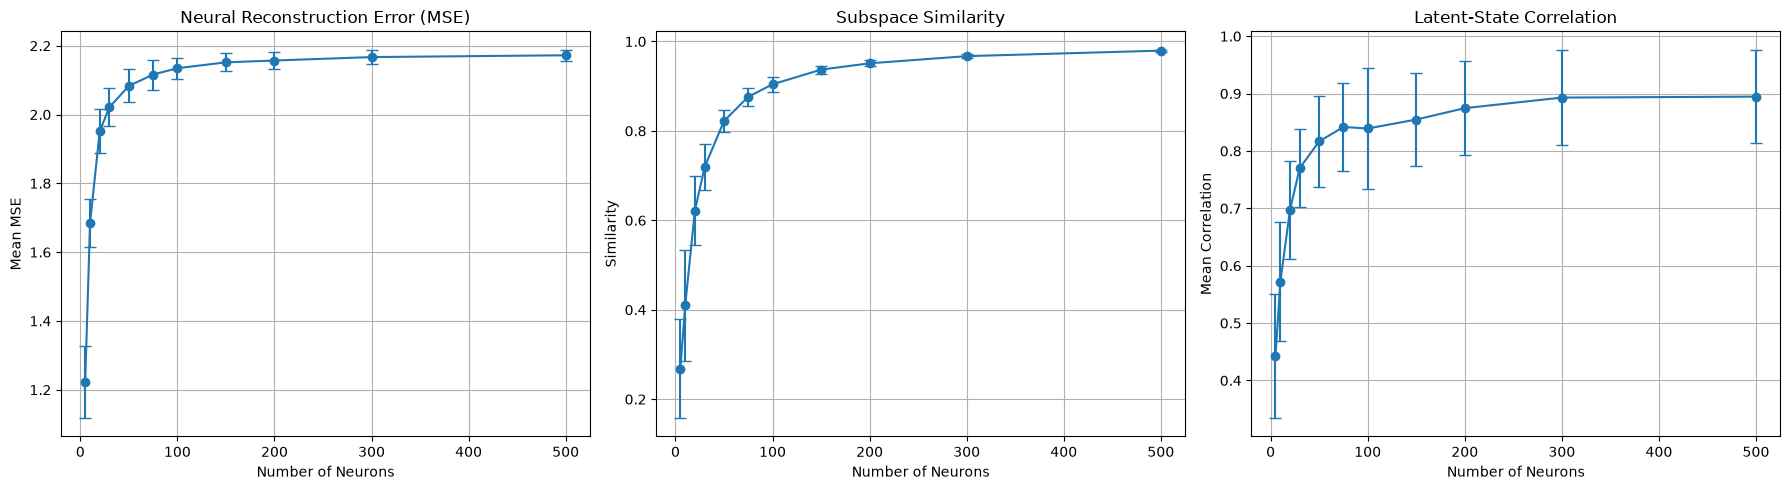

In [6]:
# Data Frame
results_df = pd.DataFrame({
    "Number of Neurons": ns,
    "mean_mse": mean_mse,
    "std_mse": std_mse,
    "mean_similarity": mean_similarity,
    "std_similarity": std_similarity,
    "mean_correlation": mean_correlation,
    "std_correlation": std_correlation,
})
display(results_df.round(4))

# Plotting

fig, ax = subplots(1, 3, figsize=(18, 5), sharex=True)

ax[0].errorbar(ns, mean_mse, yerr=std_mse, fmt='o-', capsize=4)
ax[0].set_title("Neural Reconstruction Error (MSE)")
ax[0].set_xlabel("Number of Neurons")
ax[0].set_ylabel("Mean MSE")
ax[0].grid()

# Subspace Similarity
ax[1].errorbar(ns, mean_similarity, yerr=std_similarity, fmt='o-', capsize=4)
ax[1].set_title("Subspace Similarity")
ax[1].set_xlabel("Number of Neurons")
ax[1].set_ylabel("Similarity")
ax[1].grid()

# Correlation 
ax[2].errorbar(ns, mean_correlation, yerr=std_correlation, fmt='o-', capsize=4)
ax[2].set_title("Latent-State Correlation")
ax[2].set_xlabel("Number of Neurons")
ax[2].set_ylabel("Mean Correlation")
ax[2].grid()

fig.tight_layout()

The results show that increasing the number of observed neurons substantially improves PCA's ability to recover the latent structure. As the neural population increases, both the subspace similarity score and latent-state correlation steadily increase. This indicates that the recovered principal components are increasingly accurate in capturing the true two-dimensional latent dynamics. The latent-state correlation plateaus near 0.90 instead of 1.0. This is due to PCA's arbitrary rotation and sign ambiguity within the recovered subspace, reflecting a known limitation of the Pearson correlation as a recovery metric. 

Contrary to the other metrics, the neural reconstruction error increases slightly as the number of observed neurons grow. This metric measures reconstruction of the noisy neural activity matrix instead of the recovery of the latent state itself. Therefore, it should be interpreted separately from the latent recovery metrics. As additional neurons are added, PCA must approximate a larger dataset with the same two-dimensional representation. Thus, more observation noise remains outside the recovered subspace resulting in a modest increase in reconstruction error despite improved recovery of the underlying latent dynamics. 

The improvements in recovery become progressively smaller beyond approximately 150-200 neurons. This suggests diminishing returns as additional neurons provide redundant information about the same underlying neural state. Also, the small standard deviations across repeated simulations indicate that the results are highly reproducible. Overall, these experiments showcase that larger neural populations substantially improve PCA recovery of the hidden latent structure by providing more independent measurements of the same low-dimensional dynamical system.

## Conclusion

Overall, these experiments show that PCA is most effective when the neural signal is sufficiently strong and enough neurons are observed. Recovery worsens as observation noise increases and it improves as additional neurons are provided, thus highlighting the conditions which PCA is an effective tool for recovering low-dimensional data. 